# <font color='blue'>**Tutorial: RNN and LSTM for movie review (IMDB) classification**</font>

In [ ]:
# installation of required packages - portallocker, torchtext, torchinfo,---
!pip -q install portalocker
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q torchtext==0.15.2
!pip install -q torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.7/166.7 MB 2.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchtext 0.15.2 requires torch==2.0.1, but you have torch 2.6.0+cu118 which is incompatible.
torchdata 0.6.1 requires torch==2.0.1, but you have torch 2.6.0+cu118 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.6.0+cu124 requires torch==2.6.0, but you have torch 2.0.1 which is incompatible.
torchvision 0.21.0+cu124 requires torch==2.6.0, but you have torch 2.0.1 which is incompatible.


<font color='blue'>**Tasks -**
*   Download the IMDB reviews dataste from torchtext.datasets
*   Show some samples from the dataset </font>

In [ ]:
from torchtext.datasets import IMDB
train_data, test_data = IMDB(split=('train', 'test'))

In [ ]:
# Convert to list to get length
train_length = sum(1 for _ in train_data)
test_length = sum(1 for _ in test_data)

print("Train data length:", train_length)
print("Test data length:", test_length)

Train data length: 25000
Test data length: 25000


In [ ]:
for i, sample in enumerate(train_data):
    if i == 3:  # Show only 3 samples
        break
    print(sample)  # Each sample is a tuple (label, text)

(1, 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between

<font color='blue'>**Tasks - Preprocess the text data using nltk library to perform the following:**
*   Removing stopwords
*   Removing punctuations
*   Tokenization
*   Converting text tokens to numerical data (using torchtext.vocab)
*   One hot encoding of labels</font>

In [ ]:
import nltk
nltk.download('punkt', force=True)
nltk.download('stopwords', force=True)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
import torchtext
import string
from torchtext.datasets import IMDB
from torchtext.vocab import build_vocab_from_iterator
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchinfo import summary  # For displaying summary of model
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [ ]:
# Define stopwords and punctuation set
stop_words = set(stopwords.words('english'))
punctuations = set(string.punctuation)

# Load dataset and store it in lists
train_data = list(IMDB(split='train'))
test_data = list(IMDB(split='test'))

# Preprocessing function
def preprocess_text(text):
    tokens = word_tokenize(text.lower())  # Tokenization & lowercase
    tokens = [word for word in tokens if word not in stop_words and word not in punctuations]  # Remove stopwords & punctuation
    return tokens

# Build vocabulary from training dataset
def yield_tokens(data_iter):
    for _, text in data_iter:
        yield preprocess_text(text)

# Reload dataset for iteration
train_data, test_data = IMDB(split=('train', 'test'))
vocab = build_vocab_from_iterator(yield_tokens(train_data), specials=["<unk>"])
vocab.set_default_index(vocab["<unk>"])

# Numerical encoding function
def numericalize(text):
    return vocab(preprocess_text(text))

# Process dataset
processed_train = [(label, numericalize(text)) for label, text in train_data]
processed_test = [(label, numericalize(text)) for label, text in test_data]

# Show 3 samples
for i in range(3):
    print(processed_train[i])

(1, [1420, 37499, 288, 1015, 7101, 3186, 26, 511, 22245, 23, 429, 26, 20640, 2193, 9395, 48, 655, 2347, 562, 1432, 228, 35, 1016, 7, 2928, 6, 14, 16, 15301, 1, 1, 42, 5808, 94, 91, 3704, 359, 1292, 630, 4177, 363, 700, 175, 46, 693, 363, 1000, 11860, 149, 316, 544, 739, 31002, 105, 650, 863, 1180, 2532, 230, 1401, 1180, 2200, 1475, 2023, 7165, 1808, 20018, 22027, 4597, 2236, 285, 359, 1547, 8055, 876, 12028, 1, 1, 936, 37499, 1519, 66, 473, 1016, 8253, 14, 285, 867, 57, 137, 12, 2, 217, 9, 6529, 27, 4449, 24234, 239, 74, 1473, 525, 285, 867, 535, 10155, 3704, 326, 12, 14632, 4287, 4472, 1341, 10, 78, 320, 191, 1571, 285, 57, 3859, 1, 1, 12648, 890, 97, 285, 479, 4, 479, 1443, 5132, 142, 1387, 22, 29, 172, 479, 8253, 2083, 707, 37499, 10, 4, 148, 1598, 1895, 3629, 19379, 5131, 1262, 3704, 326, 14, 4, 5, 18, 42])
(1, [7, 1829, 4351, 6, 19470, 1772, 8577, 2266, 5, 432, 8, 2, 863, 2574, 4, 818, 483, 498, 558, 2106, 7123, 794, 867, 7776, 11734, 5, 183, 55, 38, 11147, 35, 794, 867, 2265, 131

<font color='blue'>**Tasks -**
*   Divide the dataset into training, validation and test sets (70%, 15%, 15%). Add padding to the training set samples such that all samples are of equal length (for efficient minibatching) </font>

In [ ]:
import torch
import random

# Define max length and padding token
MAX_LEN = 256
PAD_TOKEN = 0  # Assuming the padding token index is 0

# Combine train and test sets
full_data = processed_train + processed_test
random.shuffle(full_data)  # Shuffle before splitting

# Split dataset: 70% train, 15% validation, 15% test
train_size = int(0.7 * len(full_data))
val_size = int(0.15 * len(full_data))

train_data = full_data[:train_size]
val_data = full_data[train_size:train_size + val_size]
test_data = full_data[train_size + val_size:]

# Function to apply padding
def pad_sequence(seq, max_len=MAX_LEN):
    seq = torch.tensor(seq) if not isinstance(seq, torch.Tensor) else seq  # Ensure tensor
    if len(seq) < max_len:
        seq = torch.cat([seq, torch.full((max_len - len(seq),), PAD_TOKEN, dtype=torch.long)])
    else:
        seq = seq[:max_len]
    return seq

# Apply padding
processed_train = [(label, pad_sequence(text)) for label, text in train_data]
processed_val = [(label, pad_sequence(text)) for label, text in val_data]
processed_test = [(label, pad_sequence(text)) for label, text in test_data]

# Show 3 samples
for i in range(3):
    print(processed_train[i])


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.11/dist-package

(2, tensor([ 1520,    62,   105,    62,     0,  2250,   544,    96,    39,    38,
        11836,   784,   231,  7466,    22,   517,     0, 26895,    90,  2563,
          137,  8651,  1293,  2912,   288, 11810,  2484,   544,  1293, 15418,
         3353,   844,   205,  2542,   288,   784,  2239, 15418,  4610,   669,
          354,  5801, 70905,   542,   972, 10977,     0,   263,    62,   116,
         1238,   758,    31,  2326,    59,     9,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,    

In [ ]:
# Extract labels from all datasets
all_labels = {label for label, _ in processed_train} | \
             {label for label, _ in processed_val} | \
             {label for label, _ in processed_test}

# Print unique labels
print("Unique labels:", all_labels)

Unique labels: {1, 2}


In [ ]:
# Function to re-encode labels
def encode_label(label):
    return 0 if label == 1 else 1  # Convert 1 → 0 and 2 → 1

# Apply label encoding
processed_train = [(encode_label(label), text) for label, text in processed_train]
processed_val = [(encode_label(label), text) for label, text in processed_val]
processed_test = [(encode_label(label), text) for label, text in processed_test]

# Verify unique labels after encoding
all_labels = {label for label, _ in processed_train} | \
             {label for label, _ in processed_val} | \
             {label for label, _ in processed_test}

print("Unique labels after encoding:", all_labels)

Unique labels after encoding: {0, 1}


<font color='blue'>**Tasks - RNNcell Modeling:**
*   Design a bidirectional vanilla RNN using PyTorch to perfom sentiment classification on this dataset. (with RNNcell)
*   Train the vanilla RNN model on the dataset using Adam, and show the variation of the training and validation losses.
*   Evaluate the trained model on the test set and evaluate its performance in terms of accuracy, precision and recall.  
*   Display the model architecture using torch.summary()</font>

In [ ]:
# Hyperparameters
EMBED_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
NUM_CLASSES = 2  # Since we have labels {0,1}
BATCH_SIZE = 128
EPOCHS = 8
VOCAB_SIZE = len(vocab)  # Vocabulary size

In [ ]:
# Define the BiRNN Model
class BiRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout=0.1):
        super(BiRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # padding_idx=0 ensures that padding tokens (index 0) have zero embeddings.

        # Separate forward and backward RNNCells
        self.rnn_fwd = nn.ModuleList([nn.RNNCell(embed_dim if i == 0 else hidden_dim, hidden_dim) for i in range(num_layers)])
        self.rnn_bwd = nn.ModuleList([nn.RNNCell(embed_dim if i == 0 else hidden_dim, hidden_dim) for i in range(num_layers)])

        self.dropout = nn.Dropout(dropout)  # Dropout layer with probability 0.1
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # Fully connected layer
        # projects the concatenated forward and backward hidden states (hidden_dim * 2) into num_classes output dimensions.

    def forward(self, x):
        embedded = self.embedding(x)  # (batch, seq_len, embed_dim)
        batch_size, seq_len, _ = embedded.size()

        # Initialize hidden states
        h_fwd = [torch.zeros(batch_size, HIDDEN_DIM, device=x.device) for _ in range(NUM_LAYERS)]
        h_bwd = [torch.zeros(batch_size, HIDDEN_DIM, device=x.device) for _ in range(NUM_LAYERS)]

        # Forward RNN Pass
        for t in range(seq_len):
            for i in range(NUM_LAYERS):
                h_fwd[i] = self.rnn_fwd[i](embedded[:, t, :] if i == 0 else h_fwd[i-1], h_fwd[i])

        # Backward RNN Pass
        for t in reversed(range(seq_len)):
            for i in range(NUM_LAYERS):
                h_bwd[i] = self.rnn_bwd[i](embedded[:, t, :] if i == 0 else h_bwd[i-1], h_bwd[i])

        # Concatenate final hidden states
        h_final = torch.cat((h_fwd[-1], h_bwd[-1]), dim=1)  # (batch, 2*hidden_dim)

        # Apply Dropout
        h_final = self.dropout(h_final)

        # Fully connected layer
        out = self.fc(h_final)
        return out

In [ ]:
# Convert data to tensors
from torch.utils.data import DataLoader, TensorDataset

def create_dataloader(processed_data, batch_size):
    labels = torch.tensor([label for label, _ in processed_data], dtype=torch.long)
    sequences = torch.stack([text for _, text in processed_data])  # Stack tensors
    dataset = TensorDataset(sequences, labels)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Create DataLoaders
train_loader = create_dataloader(processed_train, BATCH_SIZE)
val_loader = create_dataloader(processed_val, BATCH_SIZE)
test_loader = create_dataloader(processed_test, BATCH_SIZE)

Epoch [1/8], Train Loss: 0.6710, Val Loss: 0.6419
Epoch [2/8], Train Loss: 0.6214, Val Loss: 0.6219
Epoch [3/8], Train Loss: 0.5931, Val Loss: 0.5955
Epoch [4/8], Train Loss: 0.5642, Val Loss: 0.5833
Epoch [5/8], Train Loss: 0.5469, Val Loss: 0.5792
Epoch [6/8], Train Loss: 0.5680, Val Loss: 0.6225
Epoch [7/8], Train Loss: 0.5464, Val Loss: 0.5933
Epoch [8/8], Train Loss: 0.5477, Val Loss: 0.5778
Training complete.


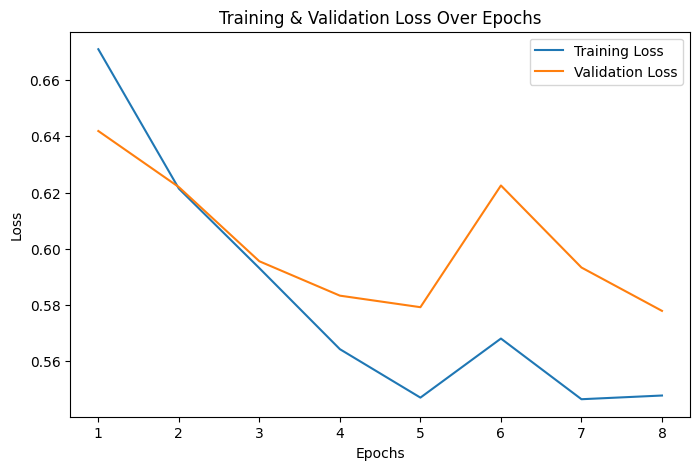

In [ ]:
# Define model, loss, and optimizer
vocab_size = len(vocab)  # Change this based on your vocab size
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BiRNN(vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

import matplotlib.pyplot as plt

# Training loop with loss visualization
def train_model(model, train_loader, val_loader, epochs):
    model.train()
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        total_train_loss = 0
        model.train()  # Ensure model is in training mode

        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        # Compute validation loss
        model.eval()  # Switch to evaluation mode
        total_val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                total_val_loss += loss.item()

        # Calculate average loss
        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    print("Training complete.")

    # Plot loss variation
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, epochs + 1), train_losses, label="Training Loss")
    plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training & Validation Loss Over Epochs")
    plt.show()

# Train the model
train_model(model, train_loader, val_loader, EPOCHS)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Function to evaluate model performance
def evaluate_model(model, data_loader):
    model.eval()
    correct, total = 0, 0
    all_preds = []   # initializing the lists
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            _, predicted = torch.max(outputs, 1)

            # Store predictions and actual labels
            all_preds.extend(predicted.cpu().tolist())  # Use .tolist()
            all_labels.extend(batch_y.cpu().tolist())

            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)

    # Compute accuracy
    accuracy = correct / total

    # Compute precision, recall, and F1-score
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

# Evaluate on test set
evaluate_model(model, test_loader)

Accuracy:  0.7145
Precision: 0.7167
Recall:    0.7145
F1-score:  0.7136


In [ ]:
# Fetch one batch from train_loader
actual_input, _ = next(iter(train_loader))  # Get batch_x (ignore batch_y)

# Ensure the input is of type LongTensor
actual_input = actual_input.to(dtype=torch.long, device=device)

# Display model summary
summary(model, input_data=actual_input, col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
BiRNN                                    [128, 256]                [128, 2]                  --                        True
├─Embedding: 1-1                         [128, 256]                [128, 256, 128]           14,291,200                True
├─ModuleList: 1-2                        --                        --                        --                        True
│    └─RNNCell: 2-1                      [128, 128]                [128, 256]                98,816                    True
│    └─RNNCell: 2-2                      [128, 256]                [128, 256]                131,584                   True
│    └─RNNCell: 2-3                      [128, 128]                [128, 256]                (recursive)               True
│    └─RNNCell: 2-4                      [128, 256]                [128, 256]                (recursive)               True
│  

In [ ]:
## ------------------------------LSTM with cell-------------------

<font color='blue'>**Tasks - LSTMcell Modeling:**
*   Design a bidirectional vanilla LSTM using PyTorch to perfom sentiment classification on this dataset. (with LSTMcell)
*   Train the LSTM model on the dataset using Adam, and show the variation of the training and validation losses.
*   Evaluate the trained model on the test set and evaluate its performance in terms of accuracy, precision and recall.  
*   Display the model architecture using torch.summary()</font>

In [ ]:
import torch
import torch.nn as nn

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.1):
        super(BiLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm_fwd = nn.LSTMCell(embed_dim, hidden_dim)  # Forward LSTM cell
        self.lstm_bwd = nn.LSTMCell(embed_dim, hidden_dim)  # Backward LSTM cell
        self.dropout = nn.Dropout(dropout)  # Dropout layer with probability 0.1
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # Fully connected output layer

    def forward(self, x):
        embedded = self.embedding(x)  # Shape: (batch_size, seq_len, embed_dim)
        batch_size, seq_len, _ = embedded.shape

        # Initialize Hidden & Cell States
        h_fwd, c_fwd = torch.zeros(batch_size, HIDDEN_DIM).to(x.device), torch.zeros(batch_size, HIDDEN_DIM).to(x.device)
        h_bwd, c_bwd = torch.zeros(batch_size, HIDDEN_DIM).to(x.device), torch.zeros(batch_size, HIDDEN_DIM).to(x.device)

        outputs_fwd, outputs_bwd = [], []

        # Forward LSTM pass
        for t in range(seq_len):
            h_fwd, c_fwd = self.lstm_fwd(embedded[:, t, :], (h_fwd, c_fwd))
            outputs_fwd.append(h_fwd)

        # Backward LSTM pass
        for t in reversed(range(seq_len)):
            h_bwd, c_bwd = self.lstm_bwd(embedded[:, t, :], (h_bwd, c_bwd))
            outputs_bwd.append(h_bwd)

        outputs_fwd = torch.stack(outputs_fwd, dim=1)  # (batch_size, seq_len, hidden_dim)
        outputs_bwd = torch.stack(outputs_bwd[::-1], dim=1)  # Reverse to align with forward

        final_output = torch.cat((outputs_fwd[:, -1, :], outputs_bwd[:, 0, :]), dim=1)  # Concatenate last fwd & first bwd

        # Apply Dropout
        final_output = self.dropout(final_output)

        return self.fc(final_output)

Epoch [1/8], Train Loss: 0.6578, Val Loss: 0.5651
Epoch [2/8], Train Loss: 0.5258, Val Loss: 0.4937
Epoch [3/8], Train Loss: 0.4557, Val Loss: 0.4408
Epoch [4/8], Train Loss: 0.3984, Val Loss: 0.3954
Epoch [5/8], Train Loss: 0.3505, Val Loss: 0.3845
Epoch [6/8], Train Loss: 0.3228, Val Loss: 0.3658
Epoch [7/8], Train Loss: 0.2952, Val Loss: 0.3506
Epoch [8/8], Train Loss: 0.2747, Val Loss: 0.3402
Training complete.


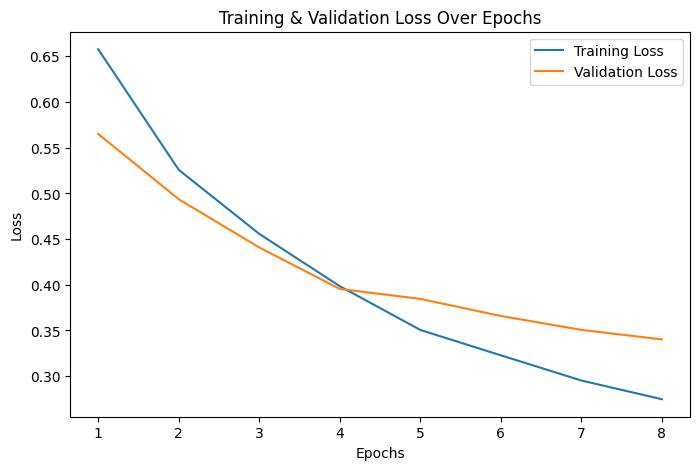

In [ ]:
model1 = BiLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Define Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model1.parameters(), lr=0.0001, weight_decay=1e-5)

# Train the model using the SAME function
train_model(model1, train_loader, val_loader, EPOCHS)

In [ ]:
evaluate_model(model1, test_loader)

Accuracy:  0.8549
Precision: 0.8561
Recall:    0.8549
F1-score:  0.8549


In [ ]:
# Display model summary
summary(model1, input_data=actual_input, col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
BiLSTM                                   [128, 256]                [128, 2]                  --                        True
├─Embedding: 1-1                         [128, 256]                [128, 256, 128]           14,291,200                True
├─LSTMCell: 1-2                          [128, 128]                [128, 256]                395,264                   True
├─LSTMCell: 1-3                          [128, 128]                [128, 256]                (recursive)               True
├─LSTMCell: 1-4                          [128, 128]                [128, 256]                (recursive)               True
├─LSTMCell: 1-5                          [128, 128]                [128, 256]                (recursive)               True
├─LSTMCell: 1-6                          [128, 128]                [128, 256]                (recursive)               True
├─L

In [ ]:
#--------------------LSTM without cell--------------------------

<font color='blue'>**Tasks - LSTM Modeling:**
*   Design a bidirectional vanilla LSTM using PyTorch to perfom sentiment classification on this dataset. (with nn.LSTM)
*   Train the LSTM model on the dataset using Adam, and show the variation of the training and validation losses.
*   Evaluate the trained model on the test set and evaluate its performance in terms of accuracy, precision and recall.  
*   Display the model architecture using torch.summary()</font>

In [ ]:
import torch.nn as nn

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes):
        super(BiLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.1)  # Dropout layer
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # 2 for bidirectional

    def forward(self, x):
        x = self.embedding(x)
        x = self.dropout(x)  # Apply dropout after embedding
        lstm_out, _ = self.lstm(x)  # LSTM handles hidden state internally
        lstm_out = self.dropout(lstm_out)  # Apply dropout after LSTM
        out = self.fc(lstm_out[:, -1, :])  # Use the last time step
        return out

Epoch [1/8], Train Loss: 0.6932, Val Loss: 0.6932
Epoch [2/8], Train Loss: 0.6916, Val Loss: 0.6908
Epoch [3/8], Train Loss: 0.6832, Val Loss: 0.6908
Epoch [4/8], Train Loss: 0.6654, Val Loss: 0.5982
Epoch [5/8], Train Loss: 0.4928, Val Loss: 0.4526
Epoch [6/8], Train Loss: 0.3589, Val Loss: 0.4243
Epoch [7/8], Train Loss: 0.2824, Val Loss: 0.3876
Epoch [8/8], Train Loss: 0.2369, Val Loss: 0.3995
Training complete.


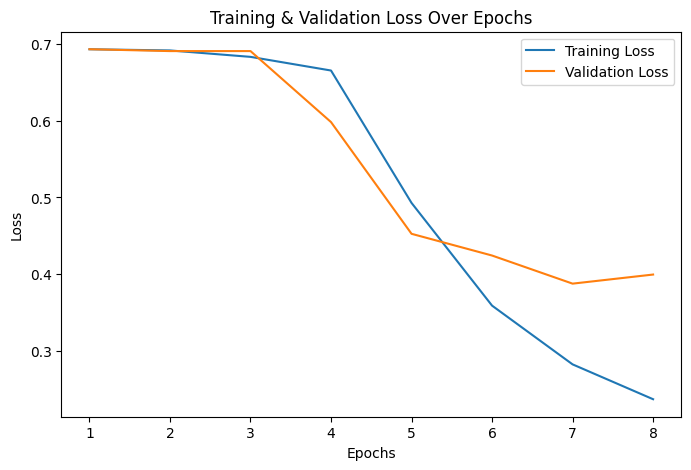

In [ ]:
# Define model, loss, and optimizer
EMBED_DIM = 128
HIDDEN_DIM = 128
model_lstm = BiLSTM(vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_lstm.parameters(), lr=0.0005)

# Train the model
train_model(model_lstm, train_loader, val_loader, EPOCHS)

In [ ]:
evaluate_model(model_lstm, test_loader)

Accuracy:  0.8579
Precision: 0.8583
Recall:    0.8579
F1-score:  0.8579


In [ ]:
# Display model summary
summary(model_lstm, input_data=actual_input, col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
BiLSTM                                   [128, 256]                [128, 2]                  --                        True
├─Embedding: 1-1                         [128, 256]                [128, 256, 128]           14,291,200                True
├─Dropout: 1-2                           [128, 256, 128]           [128, 256, 128]           --                        --
├─LSTM: 1-3                              [128, 256, 128]           [128, 256, 256]           659,456                   True
├─Dropout: 1-4                           [128, 256, 256]           [128, 256, 256]           --                        --
├─Linear: 1-5                            [128, 256]                [128, 2]                  514                       True
Total params: 14,951,170
Trainable params: 14,951,170
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 23.44
Input size (